### Agglomerative clustering, example 2 (Online products)

This is a bit more realistic situation where Agglomerative clustering could be used (too many options)

In [14]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [15]:
# load and test dataset
df = pd.read_csv("shopping.csv")
df = df.dropna()
df

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Avg_Price,Delivery_Charges,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct
0,0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.10,1/1/2019,4500.0,2424.50,1,ELEC10,10.0
1,1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.10,1/1/2019,4500.0,2424.50,1,ELEC10,10.0
2,2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,122.77,6.5,Not Used,0.10,1/1/2019,4500.0,2424.50,1,ELEC10,10.0
3,3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,81.50,6.5,Clicked,0.10,1/1/2019,4500.0,2424.50,1,ELEC10,10.0
4,4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Clicked,0.10,1/1/2019,4500.0,2424.50,1,ELEC10,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,52919,13155.0,F,California,8.0,22504.0,2019-03-10,GGOEGGCX056399,Gift Card - $250.00,Gift Cards,...,250.00,0.0,Clicked,0.05,3/10/2019,2500.0,1294.22,3,GC30,30.0
52920,52920,18077.0,M,Chicago,34.0,24250.0,2019-03-28,GGOEGGCX056299,Gift Card - $25.00,Gift Cards,...,25.00,0.0,Used,0.05,3/28/2019,2000.0,1066.12,3,GC30,30.0
52921,52921,16085.0,M,California,15.0,39991.0,2019-10-06,GGOEGOCD078399,Google Leather Perforated Journal,Notebooks & Journals,...,10.80,6.0,Clicked,0.05,10/6/2019,3000.0,2230.76,10,NJ10,10.0
52922,52922,16085.0,M,California,15.0,39991.0,2019-10-06,GGOEGOCR078499,Google Spiral Leather Journal,Notebooks & Journals,...,9.60,6.0,Used,0.05,10/6/2019,3000.0,2230.76,10,NJ10,10.0


In [16]:
df['Product_Description'].value_counts()

Product_Description
Nest Learning Thermostat 3rd Gen-USA - Stainless Steel         3511
Nest Cam Outdoor Security Camera - USA                         3328
Nest Cam Indoor Security Camera - USA                          3230
Google Sunglasses                                              1523
Nest Protect Smoke + CO White Battery Alarm-USA                1361
                                                               ... 
Google Tee Red                                                    2
Compact Journal with Recycled Pages                               1
Android Women's Short Sleeve Tri-blend Badge Tee Light Blue       1
Google Women's Colorblock Tee White                               1
Google Large Standard Journal Grey                                1
Name: count, Length: 395, dtype: int64

In [17]:
# encode the day as NUMERIC labels
# this is only used by one of the metrics => ARI
encoder_day = LabelEncoder()
df['Category_encoded'] = encoder_day.fit_transform(df['Product_Description'])

df[['Product_Description', "Category_encoded"]]

,Product_Description,Category_encoded
0,Nest Learning Thermostat 3rd Gen-USA - Stainle...,308
1,Nest Learning Thermostat 3rd Gen-USA - Stainle...,308
2,Nest Cam Outdoor Security Camera - USA,304
3,Nest Protect Smoke + CO White Battery Alarm-USA,313
4,Nest Learning Thermostat 3rd Gen-USA - Stainle...,308
...,...,...
52919,Gift Card - $250.00,94
52920,Gift Card - $25.00,93
52921,Google Leather Perforated Journal,138
52922,Google Spiral Leather Journal,199


**Process all variables (numeric and categoricals)**

In [18]:
df.columns

Index(['Unnamed: 0', 'CustomerID', 'Gender', 'Location', 'Tenure_Months',
       'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'GST', 'Date', 'Offline_Spend',
       'Online_Spend', 'Month', 'Coupon_Code', 'Discount_pct',
       'Category_encoded'],
      dtype='object')

In [19]:
# create helper lists for numeric and categorical variables
features_numeric = ['Quantity', 'Avg_Price', 'Offline_Spend', 'Online_Spend', 'Discount_pct']
features_categorical = ['Coupon_Status', 'Gender', 'Location']

# MODIFY THIS SO THAT BINARY-CATEGORIES ARE HANDLED SEPARATELY

# one-hot encode categoricals
encoder = OneHotEncoder(sparse_output=False)
encoded_cats = encoder.fit_transform(df[features_categorical])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(features_categorical))

# combine numeric + encoded categorical
X = pd.concat([df[features_numeric].reset_index(drop=True), encoded_cat_df.reset_index(drop=True)], axis=1)

### Values need to be scaled

In [20]:
# scale only the numeric features
scaler = StandardScaler()
X[features_numeric] = scaler.fit_transform(X[features_numeric])

**Perform clustering**

In [21]:
# amount of clusters, usually it should be less than the options you have
n_clusters = 20

clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df['Cluster'] = clusterer.fit_predict(X)

**Metrics**

In [22]:
# if you can get both these metrics either 1 or very close to 1
# is means the clustering describes the original structure extremely well
# and you can replace the original high cardinality column with the cluster values instead

sil_score = silhouette_score(X, df['Cluster'])
print(f"Silhouette Score: {sil_score:.4f}")

ari_score = adjusted_rand_score(df['Category_encoded'], df['Cluster'])
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

Silhouette Score: 0.0750
Adjusted Rand Index (ARI): 0.0361


In [23]:
# 1Count occurrences of Product_Category within each Cluster
counts = df.groupby(['Cluster', 'Product_Category']).size().reset_index(name='count')

# For each Cluster, find the Product_Category with the maximum count
most_popular = counts.loc[counts.groupby('Cluster')['count'].idxmax()]

# sort by cluster
most_popular = most_popular.sort_values('Cluster').reset_index(drop=True)
most_popular

,Cluster,Product_Category,count
0,0,Nest-USA,1314
1,1,Apparel,1300
2,2,Office,32
3,3,Apparel,2322
4,4,Apparel,2907
5,5,Nest-USA,3732
6,6,Office,162
7,7,Apparel,1855
8,8,Nest-USA,828
9,9,Nest-USA,239


In [24]:
results = df[['Cluster', 'Product_Category']].value_counts().sort_index()
results

Cluster  Product_Category
0        Accessories           27
         Android                1
         Apparel             1026
         Bags                  65
         Bottles                2
                             ... 
18       Office               380
         Waze                  36
19       Gift Cards             1
         Nest                 610
         Nest-USA               2
Name: count, Length: 249, dtype: int64

In [25]:
# Convert the Series to DataFrame
results_df = results.reset_index(name='count')  # 'count' will be the column with counts

# Now results_df has columns: 'Cluster', 'Product_Category', 'count'

# Sort by Cluster and count descending
results_df = results_df.sort_values(['Cluster', 'count'], ascending=[True, False])

# Take top N per cluster
top_n = 3
top_categories = results_df.groupby('Cluster').head(top_n).reset_index(drop=True)

print(top_categories)


    Cluster Product_Category  count
0         0         Nest-USA   1314
1         0          Apparel   1026
2         0             Nest    385
3         1          Apparel   1300
4         1         Nest-USA   1142
5         1           Office    539
6         2           Office     32
7         2             Bags      8
8         2        Drinkware      7
9         3          Apparel   2322
10        3           Office    721
11        3        Drinkware    422
12        4          Apparel   2907
13        4           Office    984
14        4        Drinkware    542
15        5         Nest-USA   3732
16        5             Nest    437
17        5          Apparel    211
18        6           Office    162
19        6        Drinkware     48
20        6        Lifestyle     36
21        7          Apparel   1855
22        7           Office    617
23        7        Drinkware    338
24        8         Nest-USA    828
25        8          Apparel    611
26        8           Office

In [29]:
df[['Product_Description', 'Cluster']].head(30)

,Product_Description,Cluster
0,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14
1,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14
2,Nest Cam Outdoor Security Camera - USA,14
3,Nest Protect Smoke + CO White Battery Alarm-USA,10
4,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14
5,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14
6,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14
7,Nest Protect Smoke + CO White Battery Alarm-USA,14
8,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14
9,Nest Learning Thermostat 3rd Gen-USA - Stainle...,14


In [ ]:
# it's all about a compromise => average clustering result vs too many one hot encoded variables
# too many one hot encoded variables bring usually noise to the dataset

# this is one of the big dilemmas in ML engineering => how to handle categoricals
# should everything be a separate variable? (huge amounts of potential noise)
# technically the noise here is a form of variance and sparsity of values

# or should we use agglomerative clustering (one variable, but lost 
# accuracy regarding category relationships)

# NOTE: some tree-based models like Random Forest or XGBoost can handle
# nominal categories even if they are converted with a LabelEncoder (just
# random integer for each categories), since they still treat them as separate
# categories

# however, when having too many values, the tree based models can struggle
# with many options, since they have to make more and more splits between
# categories while creating the decision trees

https://www.datanovia.com/en/wp-content/uploads/dn-tutorials/003-hierarchical-clustering-in-r/figures/002-agglomerative-clustering-cutree-cut-dendrogram-1.png

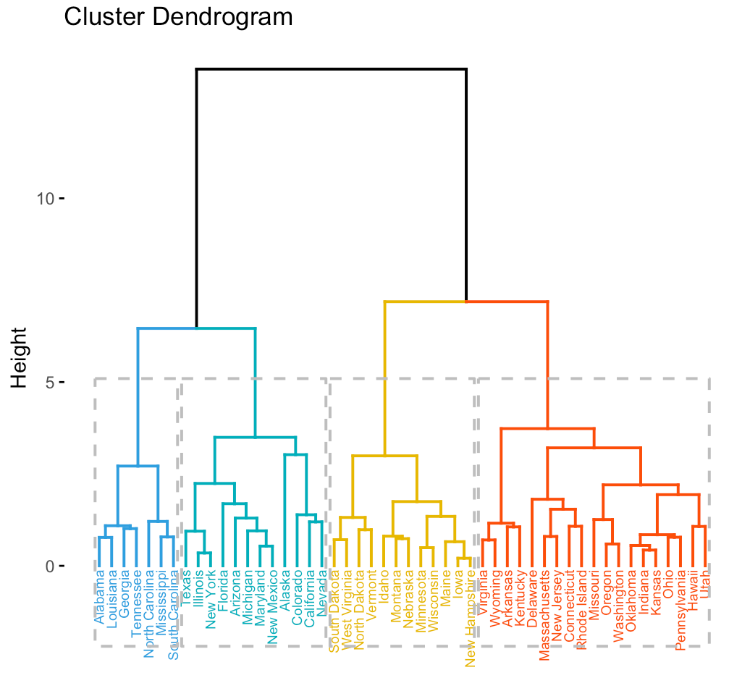